# LMM Brain-Behavior Analysis: Pre-Decision Neural, Physiological & Gaze Responses

**Purpose**: Use linear mixed models to test whether trial-level neural (EEG), physiological (pupil), and gaze signals statistically track decision-relevant variables — while rigorously controlling for subject-level differences via random intercepts.

Unlike the fusion model (which asks "can we predict the choice?"), LMMs here ask:
1. **Behavior → Neural/Physio/Gaze**: Do trial-level task variables (ambiguity, EV difference, previous outcome) drive pre-decision EEG, pupil, and gaze responses?
2. **Neural → Decision**: Do pre-decision neural signals predict invest/keep *beyond* what task parameters already explain?
3. **Mediation**: Does ambiguity affect decisions *through* the neural response?
4. **Pupil deep dive**: Why does ambiguity *decrease* pupil diameter? Is it mean diameter or dynamics?
5. **Extended EEG scan**: Do temporal dynamics (slope, std) or lateralization indices track ambiguity or decisions better than average power?
6. **Gaze deep dive**: Which gaze features are modulated by ambiguity, and which predict the investment decision?

All models use **pre-decision window** features. Random intercepts per subject absorb stable individual differences so fixed effects reflect within-subject trial-to-trial modulation.

**Data**: EEG — 80 subjects (10,212 trials); Pupil/Gaze — 102 subjects (12,107 trials).

In [103]:
import sys
sys.path.append('../..')

import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import norm, chi2
from matplotlib.lines import Line2D
import warnings
warnings.filterwarnings('ignore')

import statsmodels.formula.api as smf

sns.set_style('whitegrid')
np.random.seed(42)

print('='*70)
print('LMM BRAIN-BEHAVIOR ANALYSIS: PRE-DECISION WINDOW')
print('='*70)

LMM BRAIN-BEHAVIOR ANALYSIS: PRE-DECISION WINDOW


In [104]:
# Load behavioral + physio features
with open('../../data/features/extracted_features_PRE.pkl', 'rb') as f:
    feature_data = pickle.load(f)

merged_df     = feature_data['merged_df'].copy()
physio_cols   = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']

print(f'Behavioral/physio: {len(merged_df)} trials, {merged_df["subject_id"].nunique()} subjects')
print(f'Physio features ({len(physio_cols)}): {physio_cols}')

Behavioral/physio: 12107 trials, 102 subjects
Physio features (13): ['pupil_mean_pre', 'pupil_std_pre', 'pupil_slope_pre', 'time_to_peak_pre', 'pupil_cv_pre', 'pupil_velocity_mean_pre', 'pupil_max_dilation_rate_pre', 'pupil_max_constriction_rate_pre', 'pupil_acceleration_std_pre', 'pct_time_dilating_pre', 'num_dilation_peaks_pre', 'eye_asymmetry_pre', 'eye_asymmetry_std_pre']


In [105]:
# Load EEG features (regional_bands, pre-decision window)
with open('../../data/features/eeg_features_regional_bands.pkl', 'rb') as f:
    eeg_data = pickle.load(f)

eeg_df   = eeg_data['eeg_features_df'].copy()
eeg_cols = eeg_data['feature_columns']

print(f'EEG: {len(eeg_df)} trials, {eeg_df["subject_id"].nunique()} subjects')
print(f'EEG features ({len(eeg_cols)}): {eeg_cols}')

EEG: 10212 trials, 80 subjects
EEG features (16): ['eeg_Delta_Frontal', 'eeg_Delta_Central', 'eeg_Delta_Parietal', 'eeg_Delta_Occipital', 'eeg_Theta_Frontal', 'eeg_Theta_Central', 'eeg_Theta_Parietal', 'eeg_Theta_Occipital', 'eeg_Alpha_Frontal', 'eeg_Alpha_Central', 'eeg_Alpha_Parietal', 'eeg_Alpha_Occipital', 'eeg_Beta_Frontal', 'eeg_Beta_Central', 'eeg_Beta_Parietal', 'eeg_Beta_Occipital']


In [106]:
# Build modeling dataframes
behavior_keep = ['subject_id', 'trial_id', 'outcome',
                 'ambiguity', 'ev_difference', 'risk_premium',
                 'decision_time', 'prev_outcome', 'running_invest_rate']
pupil_keep = ['pupil_mean_pre', 'pupil_slope_pre', 'pupil_velocity_mean_pre']

base_df = merged_df[behavior_keep + pupil_keep].copy()

# EEG subset (inner join on trial_id)
df_eeg = base_df.merge(eeg_df[['trial_id'] + eeg_cols], on='trial_id', how='inner')
df_eeg = df_eeg.dropna(subset=eeg_cols + pupil_keep).reset_index(drop=True)

# Full dataset (pupil only)
df_full = base_df.dropna(subset=pupil_keep).reset_index(drop=True)

print(f'EEG modeling set:  {len(df_eeg)} trials, {df_eeg["subject_id"].nunique()} subjects')
print(f'Full modeling set: {len(df_full)} trials, {df_full["subject_id"].nunique()} subjects')

# Z-score helper
def zscore_cols(df, cols):
    df = df.copy()
    for c in cols:
        mu, sd = df[c].mean(), df[c].std()
        df[f'{c}_z'] = (df[c] - mu) / sd if sd > 0 else 0.0
    return df

z_cols = ['ambiguity', 'ev_difference', 'risk_premium', 'decision_time',
          'running_invest_rate', 'pupil_mean_pre', 'pupil_slope_pre',
          'pupil_velocity_mean_pre'] + eeg_cols

df_eeg  = zscore_cols(df_eeg,  [c for c in z_cols if c in df_eeg.columns])
df_full = zscore_cols(df_full, [c for c in z_cols if c in df_full.columns])
print('Z-scoring done.')

# Coefficient extraction helper
def extract_coefs(fit, drop='Intercept'):
    df = pd.DataFrame({'coef': fit.fe_params, 'se': fit.bse_fe, 'pval': fit.pvalues})
    if drop and drop in df.index:
        df = df.drop(drop)
    df['ci_lo'] = df['coef'] - 1.96 * df['se']
    df['ci_hi'] = df['coef'] + 1.96 * df['se']
    df['sig']   = df['pval'] < 0.05
    return df

label_map = {
    'ambiguity_z':               'Ambiguity',
    'ev_difference_z':           'EV difference',
    'risk_premium_z':            'Risk premium',
    'prev_outcome':              'Previous outcome',
    'running_invest_rate_z':     'Running invest rate',
    'eeg_Theta_Frontal_z':       'Frontal Theta',
    'eeg_Beta_Parietal_z':       'Beta Parietal',
    'eeg_Beta_Frontal_z':        'Beta Frontal',
    'pupil_mean_pre_z':          'Pupil mean',
    'pupil_slope_pre_z':         'Pupil slope',
    'pupil_velocity_mean_pre_z': 'Pupil velocity',
}

task_formula = 'ambiguity_z + ev_difference_z + prev_outcome + running_invest_rate_z'

EEG modeling set:  5437 trials, 80 subjects
Full modeling set: 12107 trials, 102 subjects
Z-scoring done.


---
## Model 1 — Behavior → Neural

**Question**: Do trial-level task variables drive pre-decision EEG, pupil, and gaze responses?

Four LMMs with subject random intercepts:
- **1a** `ambiguity + ev_difference + prev_outcome + running_invest_rate → eeg_Theta_Frontal`
- **1b** Same predictors → `eeg_Beta_Parietal` (top fusion feature by importance)
- **1c** Same predictors → `pupil_mean_pre`
- **1d** Same predictors → each of 16 gaze features (scan)

Frontal theta indexes cognitive load and uncertainty. Beta parietal is the top EEG feature in the fusion model. Pupil reflects LC-NE arousal. Gaze captures attentional allocation during deliberation.

In [107]:
m1a_fit = smf.mixedlm(f'eeg_Theta_Frontal_z ~ {task_formula}',
                      data=df_eeg, groups=df_eeg['subject_id']).fit(reml=True)
print('MODEL 1a: Task → Frontal Theta')
print(m1a_fit.summary())

MODEL 1a: Task → Frontal Theta
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: eeg_Theta_Frontal_z
No. Observations: 5437    Method:             REML               
No. Groups:       80      Scale:              0.4732             
Min. group size:  6       Log-Likelihood:     -5859.1410         
Max. group size:  122     Converged:          Yes                
Mean group size:  68.0                                           
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              -0.009    0.082 -0.107 0.915 -0.170  0.152
ambiguity_z            -0.006    0.009 -0.687 0.492 -0.025  0.012
ev_difference_z         0.007    0.009  0.696 0.486 -0.012  0.025
prev_outcome           -0.037    0.021 -1.744 0.081 -0.078  0.005
running_invest_rate_z  -0.001    0.019 -0.078 0.937 -0.038 

In [108]:
m1b_fit = smf.mixedlm(f'eeg_Beta_Parietal_z ~ {task_formula}',
                      data=df_eeg, groups=df_eeg['subject_id']).fit(reml=True)
print('MODEL 1b: Task → Beta Parietal')
print(m1b_fit.summary())

MODEL 1b: Task → Beta Parietal
              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: eeg_Beta_Parietal_z
No. Observations: 5437    Method:             REML               
No. Groups:       80      Scale:              0.5470             
Min. group size:  6       Log-Likelihood:     -6239.4425         
Max. group size:  122     Converged:          Yes                
Mean group size:  68.0                                           
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              -0.025    0.075 -0.340 0.734 -0.172  0.121
ambiguity_z            -0.007    0.010 -0.708 0.479 -0.027  0.013
ev_difference_z        -0.009    0.010 -0.856 0.392 -0.028  0.011
prev_outcome           -0.034    0.023 -1.495 0.135 -0.079  0.011
running_invest_rate_z  -0.019    0.020 -0.950 0.342 -0.058 

In [109]:
m1c_fit = smf.mixedlm(f'pupil_mean_pre_z ~ {task_formula}',
                      data=df_full, groups=df_full['subject_id']).fit(reml=True)
print('MODEL 1c: Task → Pupil Mean')
print(m1c_fit.summary())

MODEL 1c: Task → Pupil Mean
             Mixed Linear Model Regression Results
Model:              MixedLM Dependent Variable: pupil_mean_pre_z
No. Observations:   12107   Method:             REML            
No. Groups:         102     Scale:              0.7322          
Min. group size:    9       Log-Likelihood:     -15500.2502     
Max. group size:    132     Converged:          Yes             
Mean group size:    118.7                                       
----------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z| [0.025 0.975]
----------------------------------------------------------------
Intercept             -0.020    0.054 -0.363 0.717 -0.126  0.087
ambiguity_z           -0.017    0.008 -2.187 0.029 -0.032 -0.002
ev_difference_z        0.001    0.008  0.129 0.897 -0.014  0.016
prev_outcome          -0.005    0.018 -0.287 0.774 -0.041  0.030
running_invest_rate_z -0.003    0.017 -0.184 0.854 -0.037  0.031
Group Var  

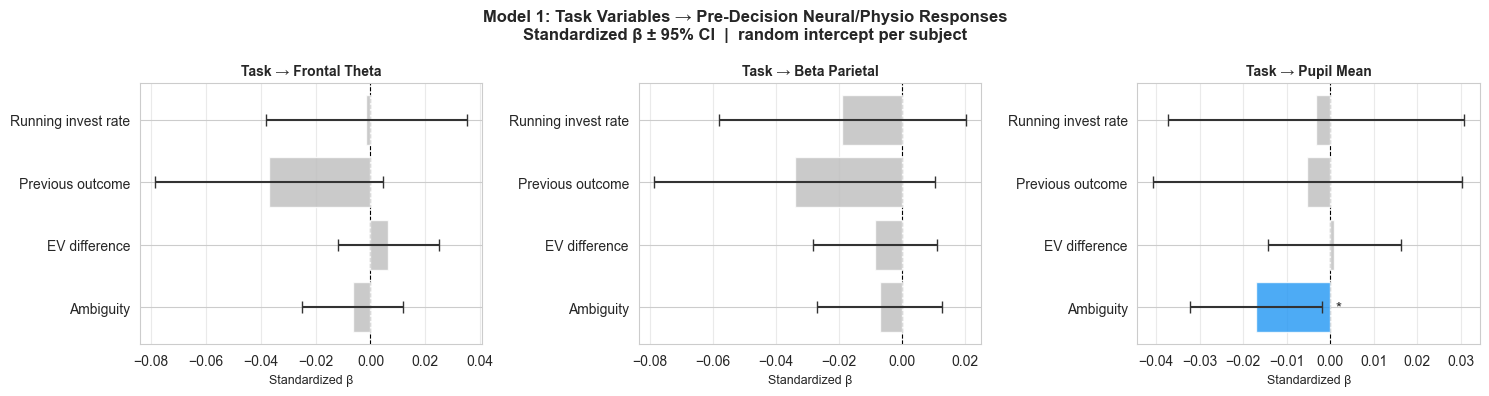

In [110]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Model 1: Task Variables → Pre-Decision Neural/Physio Responses\n'
             'Standardized β ± 95% CI  |  random intercept per subject',
             fontsize=12, fontweight='bold')

for ax, (fit, title, color) in zip(axes, [
    (m1a_fit, 'Task → Frontal Theta', '#4CAF50'),
    (m1b_fit, 'Task → Beta Parietal', '#9C27B0'),
    (m1c_fit, 'Task → Pupil Mean',    '#2196F3'),
]):
    cd = extract_coefs(fit)
    cd.index = [label_map.get(i, i) for i in cd.index]
    bar_colors = [color if s else '#BDBDBD' for s in cd['sig']]
    ax.barh(cd.index, cd['coef'], color=bar_colors, alpha=0.8, zorder=3)
    ax.errorbar(cd['coef'], cd.index,
                xerr=1.96 * cd['se'], fmt='none',
                color='#333333', capsize=4, linewidth=1.5, zorder=4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Standardized β', fontsize=9)
    ax.grid(axis='x', alpha=0.4)
    for idx, (_, row) in enumerate(cd.iterrows()):
        if row['sig']:
            ax.text(row['ci_hi'] + 0.003, idx, '*', va='center', fontsize=11)

plt.tight_layout()
Path('../../data/results/main/statistical_analyses').mkdir(parents=True, exist_ok=True)
plt.savefig('../../data/results/main/statistical_analyses/lmm_model1_behavior_to_neural.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Model 1d — Task Variables → Gaze Features

Same fixed-effect structure as 1a–1c, but with gaze as the dependent variable. We test all 16 gaze features (excluding near-constant ones) to see which are driven by trial-level task parameters.

MODEL 1d: Task → Gaze Features  (12107 trials, 102 subjects)
Significant (p < 0.05): 13 / 16 features

               feature  beta_amb   se_amb        p_amb   sig
            gaze_y_std -0.132049 0.007686 3.658308e-66  True
           gaze_x_mean -0.023714 0.008571 5.660163e-03  True
         screen_y_mean -0.018365 0.003239 1.435216e-08  True
          screen_y_std -0.000718 0.007931 9.278803e-01 False
gaze_acceleration_mean  0.009348 0.007737 2.269980e-01 False
    gaze_velocity_mean  0.010080 0.007585 1.838586e-01 False
         screen_x_mean  0.013870 0.006258 2.665265e-02  True
 gaze_acceleration_std  0.027625 0.007767 3.757572e-04  True
     gaze_velocity_std  0.028583 0.007747 2.248146e-04  True
      gaze_path_length  0.030138 0.008147 2.163701e-04  True
     gaze_dispersion_y  0.030385 0.008175 2.019354e-04  True
     gaze_velocity_max  0.041941 0.008142 2.589491e-07  True
     gaze_dispersion_x  0.054668 0.008139 1.856441e-11  True
          screen_x_std  0.056870 0.008041 1

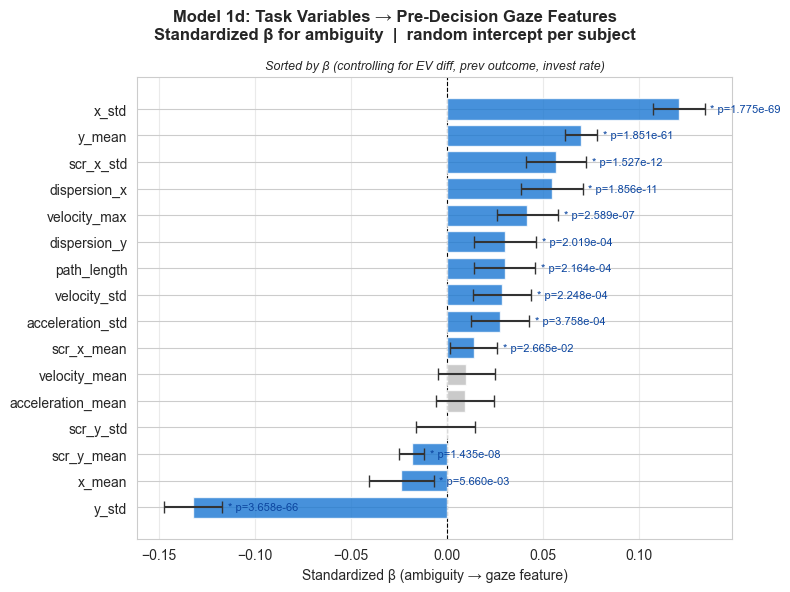

In [111]:
# Model 1d: Task Variables → Gaze Features
# Build gaze dataframe using merged_df (already loaded in cell 2)
gaze_cols_all = feature_data['gaze_cols']
gaze_m1d_cols = [c for c in gaze_cols_all if c not in
                 ['gaze_valid_pct', 'fixation_ratio', 'saccade_ratio', 'saccade_count']]

gaze_keep_m1d = ['subject_id', 'ambiguity', 'ev_difference', 'prev_outcome',
                 'running_invest_rate'] + gaze_m1d_cols
df_gaze_m1d = merged_df[gaze_keep_m1d].dropna(subset=gaze_m1d_cols).copy().reset_index(drop=True)
df_gaze_m1d = zscore_cols(df_gaze_m1d,
                          ['ambiguity', 'ev_difference', 'running_invest_rate'] + gaze_m1d_cols)

gaze_ctrl_m1d = 'ev_difference_z + prev_outcome + running_invest_rate_z'

m1d_results = []
for col in gaze_m1d_cols:
    zcol = f'{col}_z'
    if zcol not in df_gaze_m1d.columns:
        continue
    try:
        fit = smf.mixedlm(
            f'{zcol} ~ ambiguity_z + {gaze_ctrl_m1d}',
            data=df_gaze_m1d, groups=df_gaze_m1d['subject_id']
        ).fit(reml=True, disp=False)
        m1d_results.append({
            'feature':  col,
            'beta_amb': fit.fe_params['ambiguity_z'],
            'se_amb':   fit.bse_fe['ambiguity_z'],
            'p_amb':    fit.pvalues['ambiguity_z'],
        })
    except Exception:
        pass

m1d_df = pd.DataFrame(m1d_results).sort_values('beta_amb').reset_index(drop=True)
m1d_df['sig']   = m1d_df['p_amb'] < 0.05
m1d_df['ci_lo'] = m1d_df['beta_amb'] - 1.96 * m1d_df['se_amb']
m1d_df['ci_hi'] = m1d_df['beta_amb'] + 1.96 * m1d_df['se_amb']

print(f'MODEL 1d: Task → Gaze Features  ({len(df_gaze_m1d)} trials, '
      f'{df_gaze_m1d["subject_id"].nunique()} subjects)')
print(f'Significant (p < 0.05): {m1d_df["sig"].sum()} / {len(m1d_df)} features')
print()
print(m1d_df[['feature', 'beta_amb', 'se_amb', 'p_amb', 'sig']].to_string(index=False))

# Forest plot
fig, ax = plt.subplots(figsize=(8, 6))
fig.suptitle('Model 1d: Task Variables → Pre-Decision Gaze Features\n'
             'Standardized β for ambiguity  |  random intercept per subject',
             fontsize=12, fontweight='bold')

short_labels = [c.replace('gaze_', '').replace('screen_', 'scr_') for c in m1d_df['feature']]
bar_colors = ['#1976D2' if s else '#BDBDBD' for s in m1d_df['sig']]
ax.barh(short_labels, m1d_df['beta_amb'], color=bar_colors, alpha=0.8, zorder=3)
ax.errorbar(m1d_df['beta_amb'], short_labels,
            xerr=1.96 * m1d_df['se_amb'], fmt='none',
            color='#333333', capsize=4, linewidth=1.5, zorder=4)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardized β (ambiguity → gaze feature)', fontsize=10)
ax.set_title('Sorted by β (controlling for EV diff, prev outcome, invest rate)',
             fontsize=9, style='italic')
ax.grid(axis='x', alpha=0.4)
for idx, row in m1d_df.iterrows():
    if row['sig']:
        ax.text(row['ci_hi'] + 0.003, idx,
                f'* p={row["p_amb"]:.3e}', va='center', fontsize=8, color='#0D47A1')

plt.tight_layout()
plt.savefig('../../data/results/main/statistical_analyses/lmm_model1d_gaze.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Model 2 — Neural → Decision

**Question**: Do pre-decision neural signals predict invest/keep *beyond* what task parameters already explain?

Two nested LMMs compared with a likelihood ratio test:
- **Baseline**: task variables only → outcome
- **+ Neural**: Baseline + `eeg_Theta_Frontal + eeg_Beta_Parietal + pupil_mean_pre` → outcome

A significant LRT means EEG/pupil carry decision-relevant information not captured by task parameters alone.

In [112]:
m2_base_fit = smf.mixedlm(
    f'outcome ~ {task_formula}',
    data=df_eeg, groups=df_eeg['subject_id']
).fit(reml=False)
print('MODEL 2 BASELINE: Task → Outcome')
print(m2_base_fit.summary())

MODEL 2 BASELINE: Task → Outcome
              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    outcome   
No. Observations:    5437       Method:                ML        
No. Groups:          80         Scale:                 0.1844    
Min. group size:     6          Log-Likelihood:        -3200.3681
Max. group size:     122        Converged:             Yes       
Mean group size:     68.0                                        
-----------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              0.634    0.019  32.701 0.000  0.596  0.672
ambiguity_z           -0.160    0.006 -27.316 0.000 -0.171 -0.148
ev_difference_z        0.061    0.006  10.409 0.000  0.049  0.072
prev_outcome          -0.010    0.013  -0.775 0.438 -0.036  0.016
running_invest_rate_z  0.021    0.014   1.517 0.129 -0.00

In [113]:
m2_neural_fit = smf.mixedlm(
    f'outcome ~ {task_formula} + eeg_Theta_Frontal_z + eeg_Beta_Parietal_z + pupil_mean_pre_z',
    data=df_eeg, groups=df_eeg['subject_id']
).fit(reml=False)
print('MODEL 2 FULL: Task + Neural → Outcome')
print(m2_neural_fit.summary())

MODEL 2 FULL: Task + Neural → Outcome
              Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    outcome   
No. Observations:    5437       Method:                ML        
No. Groups:          80         Scale:                 0.1843    
Min. group size:     6          Log-Likelihood:        -3196.3299
Max. group size:     122        Converged:             Yes       
Mean group size:     68.0                                        
-----------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept              0.633    0.019  33.240 0.000  0.596  0.671
ambiguity_z           -0.160    0.006 -27.360 0.000 -0.171 -0.148
ev_difference_z        0.061    0.006  10.409 0.000  0.049  0.072
prev_outcome          -0.011    0.013  -0.863 0.388 -0.037  0.014
running_invest_rate_z  0.022    0.014   1.548 0.122 

In [114]:
lr_stat = -2 * (m2_base_fit.llf - m2_neural_fit.llf)
df_diff = 3
p_lrt   = chi2.sf(lr_stat, df_diff)

print('LIKELIHOOD RATIO TEST: Baseline vs. Baseline + Neural')
print(f'  LR statistic: {lr_stat:.3f},  df={df_diff},  p={p_lrt:.4e}')
print(f'  Baseline AIC: {m2_base_fit.aic:.1f}')
print(f'  + Neural AIC: {m2_neural_fit.aic:.1f}')
print(f'  ΔAIC:         {m2_base_fit.aic - m2_neural_fit.aic:.1f}  (positive = neural model better)')
print()
if p_lrt < 0.05:
    print('→ Neural signals significantly predict decisions beyond task parameters.')
else:
    print('→ Neural signals do not significantly improve fit beyond task parameters alone.')

LIKELIHOOD RATIO TEST: Baseline vs. Baseline + Neural
  LR statistic: 8.076,  df=3,  p=4.4459e-02
  Baseline AIC: 6414.7
  + Neural AIC: 6412.7
  ΔAIC:         2.1  (positive = neural model better)

→ Neural signals significantly predict decisions beyond task parameters.


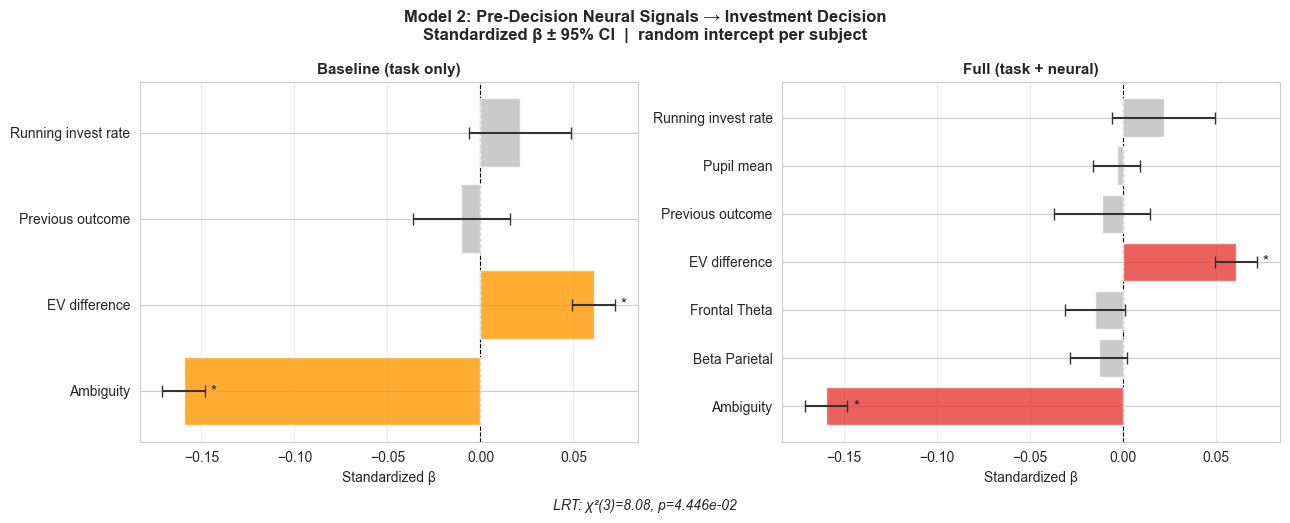

In [115]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model 2: Pre-Decision Neural Signals → Investment Decision\n'
             'Standardized β ± 95% CI  |  random intercept per subject',
             fontsize=12, fontweight='bold')

for ax, (fit, title, color) in zip(axes, [
    (m2_base_fit,   'Baseline (task only)', '#FF9800'),
    (m2_neural_fit, 'Full (task + neural)', '#E53935'),
]):
    cd = extract_coefs(fit)
    cd.index = [label_map.get(i, i) for i in cd.index]
    bar_colors = [color if s else '#BDBDBD' for s in cd['sig']]
    ax.barh(cd.index, cd['coef'], color=bar_colors, alpha=0.8, zorder=3)
    ax.errorbar(cd['coef'], cd.index,
                xerr=1.96 * cd['se'], fmt='none',
                color='#333333', capsize=4, linewidth=1.5, zorder=4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Standardized β', fontsize=10)
    ax.grid(axis='x', alpha=0.4)
    for idx, (_, row) in enumerate(cd.iterrows()):
        if row['sig']:
            ax.text(row['ci_hi'] + 0.003, idx, '*', va='center', fontsize=11)

fig.text(0.5, -0.02, f'LRT: χ²({df_diff})={lr_stat:.2f}, p={p_lrt:.3e}',
         ha='center', fontsize=10, style='italic')
plt.tight_layout()
plt.savefig('../../data/results/main/statistical_analyses/lmm_model2_neural_to_decision.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Model 3 — Mediation Analysis

**Question**: Does ambiguity affect investment decisions *through* frontal theta?

```
ambiguity ──(a)──→ Frontal Theta
    │                     │
    └──(c) total──────────┤──(b)──→ outcome
    └──(c') direct────────┘
```

Indirect effect = a × b. Tested with a Sobel test.

In [116]:
# Path c: total effect (reuse m2_base_fit — same formula, same data)
c_total   = m2_base_fit.fe_params['ambiguity_z']
c_total_p = m2_base_fit.pvalues['ambiguity_z']

# Path a: ambiguity → theta (from Model 1a)
a_coef = m1a_fit.fe_params['ambiguity_z']
a_se   = m1a_fit.bse_fe['ambiguity_z']
a_p    = m1a_fit.pvalues['ambiguity_z']

# Path b + c': from Model 2 full
b_coef    = m2_neural_fit.fe_params['eeg_Theta_Frontal_z']
b_se      = m2_neural_fit.bse_fe['eeg_Theta_Frontal_z']
b_p       = m2_neural_fit.pvalues['eeg_Theta_Frontal_z']
c_prime   = m2_neural_fit.fe_params['ambiguity_z']
c_prime_p = m2_neural_fit.pvalues['ambiguity_z']

# Sobel test
indirect = a_coef * b_coef
sobel_se = np.sqrt(b_coef**2 * a_se**2 + a_coef**2 * b_se**2)
sobel_z  = indirect / sobel_se
sobel_p  = 2 * (1 - norm.cdf(abs(sobel_z)))
prop_med = (indirect / c_total) if abs(c_total) > 1e-10 else np.nan

print('MEDIATION: Ambiguity → Frontal Theta → Decision')
print(f'  Path a (ambiguity → theta):     β={a_coef:.4f}, SE={a_se:.4f}, p={a_p:.3e}')
print(f'  Path b (theta → outcome|ambig): β={b_coef:.4f}, SE={b_se:.4f}, p={b_p:.3e}')
print(f'  Total effect (c):               β={c_total:.4f}, p={c_total_p:.3e}')
print(f"  Direct effect (c'):             β={c_prime:.4f}, p={c_prime_p:.3e}")
print(f'  Indirect (a×b):                 {indirect:.5f}')
print(f'  Sobel z={sobel_z:.3f}, p={sobel_p:.3e}')
print(f'  Proportion mediated:            {prop_med*100:.1f}%')
print()
if sobel_p < 0.05:
    if c_prime_p < 0.05:
        print(f'→ Partial mediation: {prop_med*100:.1f}% of ambiguity effect runs through frontal theta.')
    else:
        print('→ Full mediation: direct ambiguity effect absorbed by frontal theta.')
else:
    print('→ No significant mediation through frontal theta.')

MEDIATION: Ambiguity → Frontal Theta → Decision
  Path a (ambiguity → theta):     β=-0.0064, SE=0.0094, p=4.924e-01
  Path b (theta → outcome|ambig): β=-0.0149, SE=0.0083, p=7.062e-02
  Total effect (c):               β=-0.1595, p=2.714e-164
  Direct effect (c'):             β=-0.1597, p=8.103e-165
  Indirect (a×b):                 0.00010
  Sobel z=0.642, p=5.210e-01
  Proportion mediated:            -0.1%

→ No significant mediation through frontal theta.


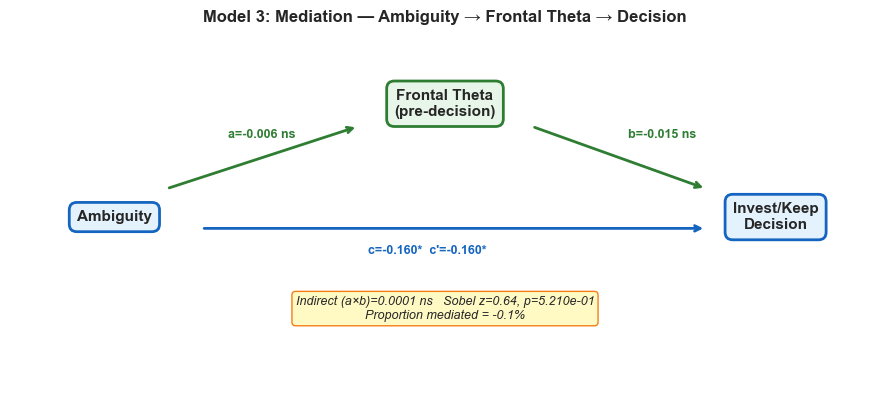

In [117]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')
fig.suptitle('Model 3: Mediation — Ambiguity → Frontal Theta → Decision',
             fontsize=12, fontweight='bold')

node_kw = dict(boxstyle='round,pad=0.5', facecolor='#E3F2FD', edgecolor='#1565C0', linewidth=2)
med_kw  = dict(boxstyle='round,pad=0.5', facecolor='#E8F5E9', edgecolor='#2E7D32', linewidth=2)

ax.text(1.2, 3,   'Ambiguity',                    ha='center', va='center', fontsize=11, fontweight='bold', bbox=node_kw)
ax.text(5.0, 5,   'Frontal Theta\n(pre-decision)', ha='center', va='center', fontsize=11, fontweight='bold', bbox=med_kw)
ax.text(8.8, 3,   'Invest/Keep\nDecision',         ha='center', va='center', fontsize=11, fontweight='bold', bbox=node_kw)

ax.annotate('', xy=(4.0, 4.6), xytext=(1.8, 3.5),
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))
ax.text(2.5, 4.4, f'a={a_coef:.3f}{"*" if a_p<0.05 else " ns"}',
        fontsize=9, color='#2E7D32', fontweight='bold')

ax.annotate('', xy=(8.0, 3.5), xytext=(6.0, 4.6),
            arrowprops=dict(arrowstyle='->', color='#2E7D32', lw=2))
ax.text(7.1, 4.4, f'b={b_coef:.3f}{"*" if b_p<0.05 else " ns"}',
        fontsize=9, color='#2E7D32', fontweight='bold')

ax.annotate('', xy=(8.0, 2.8), xytext=(2.2, 2.8),
            arrowprops=dict(arrowstyle='->', color='#1565C0', lw=2))
ax.text(4.8, 2.35,
        f'c={c_total:.3f}{"*" if c_total_p<0.05 else " ns"}  '
        f"c'={c_prime:.3f}{'*' if c_prime_p<0.05 else ' ns'}",
        ha='center', fontsize=9, color='#1565C0', fontweight='bold')

ax.text(5.0, 1.2,
        f'Indirect (a×b)={indirect:.4f}{"*" if sobel_p<0.05 else " ns"}   '
        f'Sobel z={sobel_z:.2f}, p={sobel_p:.3e}\n'
        f'Proportion mediated = {prop_med*100:.1f}%',
        ha='center', fontsize=9, style='italic',
        bbox=dict(boxstyle='round', facecolor='#FFF9C4', edgecolor='#F57F17'))

plt.tight_layout()
plt.savefig('../../data/results/main/statistical_analyses/lmm_model3_mediation.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Model 4 — Pupil Deep Dive: Ambiguity Direction & All Pupil Features

Model 1c found ambiguity significantly *decreases* pupil diameter (β = −0.017) — counterintuitive given the standard LC-NE arousal account. This section investigates:

1. **Which ambiguity levels drive it?** Treat ambiguity as categorical (Low=0, Med=3, High=6) — the linear term might mask a non-monotonic pattern.
2. **Is it mean diameter or dynamics?** Test all 13 pupil features as outcomes (slope, velocity, dilation rate, etc.).
3. **Visualize** the within-subject centered pupil mean by ambiguity level.

In [118]:
# 4a: Categorical ambiguity → pupil mean (reference = Low)
df_pupil = df_full.copy()
df_pupil['ambiguity_cat'] = pd.Categorical(
    df_pupil['ambiguity'].map({0: 'Low', 3: 'Med', 6: 'High'}),
    categories=['Low', 'Med', 'High'], ordered=True
)
df_pupil_clean = df_pupil.dropna(subset=['ambiguity_cat']).copy()

m4a_fit = smf.mixedlm(
    'pupil_mean_pre_z ~ C(ambiguity_cat, Treatment("Low")) + ev_difference_z + prev_outcome + running_invest_rate_z',
    data=df_pupil_clean,
    groups=df_pupil_clean['subject_id']
).fit(reml=True)

print('MODEL 4a: Categorical Ambiguity → Pupil Mean  (ref = Low)')
print(m4a_fit.summary())

# Within-subject centered means by ambiguity level
df_pupil['pupil_mean_centered'] = df_pupil.groupby('subject_id')['pupil_mean_pre'].transform(
    lambda x: x - x.mean()
)
group_means = df_pupil.groupby('ambiguity')['pupil_mean_centered'].agg(['mean', 'sem']).reset_index()
print('\nWithin-subject centered pupil mean by ambiguity level:')
print(group_means.to_string(index=False))

MODEL 4a: Categorical Ambiguity → Pupil Mean  (ref = Low)
                        Mixed Linear Model Regression Results
Model:                     MixedLM        Dependent Variable:        pupil_mean_pre_z
No. Observations:          12107          Method:                    REML            
No. Groups:                102            Scale:                     0.7323          
Min. group size:           9              Log-Likelihood:            -15502.4723     
Max. group size:           132            Converged:                 Yes             
Mean group size:           118.7                                                     
-------------------------------------------------------------------------------------
                                           Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------------------------
Intercept                                   0.003    0.055  0.057 0.955 -0.106  0.112
C(ambiguity_cat, Tre

In [119]:
# 4b: All 13 pupil features — which respond to ambiguity?
all_pupil_cols = [c for c in physio_cols if c.endswith('_pre')]

pupil_results = []
for col in all_pupil_cols:
    if col not in df_full.columns:
        continue
    df_tmp = df_full.dropna(subset=[col]).copy()
    mu, sd = df_tmp[col].mean(), df_tmp[col].std()
    if sd == 0:
        continue
    df_tmp[f'{col}_z'] = (df_tmp[col] - mu) / sd
    try:
        fit = smf.mixedlm(
            f'{col}_z ~ ambiguity_z + ev_difference_z + prev_outcome + running_invest_rate_z',
            data=df_tmp, groups=df_tmp['subject_id']
        ).fit(reml=True, disp=False)
        pupil_results.append({
            'feature':  col.replace('_pre', ''),
            'beta_amb': fit.fe_params['ambiguity_z'],
            'se_amb':   fit.bse_fe['ambiguity_z'],
            'p_amb':    fit.pvalues['ambiguity_z'],
        })
    except Exception:
        pass

pupil_res_df = pd.DataFrame(pupil_results).sort_values('p_amb').reset_index(drop=True)
pupil_res_df['sig']   = pupil_res_df['p_amb'] < 0.05
pupil_res_df['ci_lo'] = pupil_res_df['beta_amb'] - 1.96 * pupil_res_df['se_amb']
pupil_res_df['ci_hi'] = pupil_res_df['beta_amb'] + 1.96 * pupil_res_df['se_amb']

print('AMBIGUITY EFFECT ON ALL PUPIL FEATURES (sorted by p-value):')
print(pupil_res_df[['feature', 'beta_amb', 'se_amb', 'p_amb', 'sig']].to_string(index=False))

AMBIGUITY EFFECT ON ALL PUPIL FEATURES (sorted by p-value):
            feature  beta_amb   se_amb    p_amb   sig
        pupil_slope  0.016743 0.007054 0.017616  True
         pupil_mean -0.017011 0.007780 0.028768  True
pupil_velocity_mean -0.002586 0.006355 0.684033 False


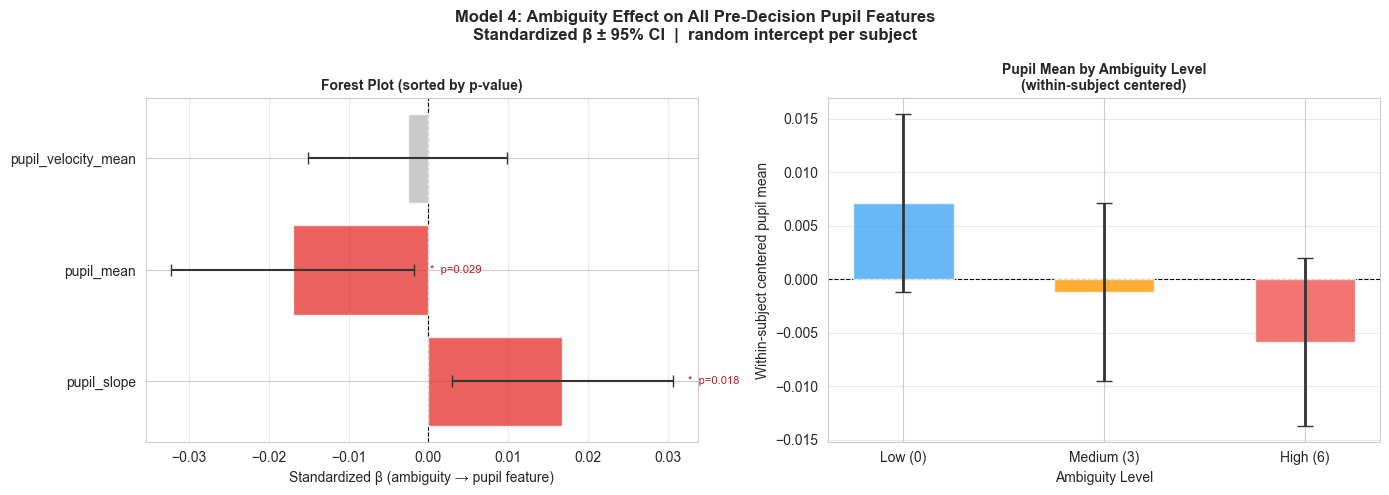

In [120]:
# 4c: Forest plot + bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model 4: Ambiguity Effect on All Pre-Decision Pupil Features\n'
             'Standardized β ± 95% CI  |  random intercept per subject',
             fontsize=12, fontweight='bold')

ax = axes[0]
bar_colors = ['#E53935' if s else '#BDBDBD' for s in pupil_res_df['sig']]
ax.barh(pupil_res_df['feature'], pupil_res_df['beta_amb'], color=bar_colors, alpha=0.8, zorder=3)
ax.errorbar(pupil_res_df['beta_amb'], pupil_res_df['feature'],
            xerr=1.96 * pupil_res_df['se_amb'], fmt='none',
            color='#333333', capsize=4, linewidth=1.5, zorder=4)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Standardized β (ambiguity → pupil feature)', fontsize=10)
ax.set_title('Forest Plot (sorted by p-value)', fontsize=10, fontweight='bold')
ax.grid(axis='x', alpha=0.4)
for idx, row in pupil_res_df.iterrows():
    if row['sig']:
        ax.text(row['ci_hi'] + 0.002, idx, f'*  p={row["p_amb"]:.3f}',
                va='center', fontsize=8, color='#B71C1C')

ax2 = axes[1]
x = list(range(len(group_means)))
amb_labels = {0: 'Low (0)', 3: 'Medium (3)', 6: 'High (6)'}
means = group_means['mean'].values
sems  = group_means['sem'].values
ax2.bar(x, means, color=['#42A5F5', '#FF9800', '#EF5350'], alpha=0.8, width=0.5, zorder=3)
ax2.errorbar(x, means, yerr=1.96 * sems, fmt='none',
             color='#333333', capsize=6, linewidth=2, zorder=4)
ax2.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax2.set_xticks(x)
ax2.set_xticklabels([amb_labels.get(int(k), str(k)) for k in group_means['ambiguity']], fontsize=10)
ax2.set_xlabel('Ambiguity Level', fontsize=10)
ax2.set_ylabel('Within-subject centered pupil mean', fontsize=10)
ax2.set_title('Pupil Mean by Ambiguity Level\n(within-subject centered)', fontsize=10, fontweight='bold')
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../../data/results/main/statistical_analyses/lmm_model4_pupil_ambiguity.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Model 5 — Extended EEG Features: Temporal Dynamics & Lateralization

The `regional_bands` features in Models 1-3 are power averaged over the full 2-second window. The `non_temporal` feature set (96 features) adds:

- **`_mean`**: average power (same as base, redundant sanity check)
- **`_std`**: variability of power within the window
- **`_slope`**: linear trend of power across the window — does activity *rise or fall* during deliberation?
- **Lateralization**: `(left − right) / (left + right)` per band — hemispheric asymmetry

We run a data-driven scan across all 96 features in both directions and plot the results.

In [121]:
# Load non_temporal EEG features
with open('../../data/features/eeg_features_non_temporal.pkl', 'rb') as f:
    eeg_nt_data = pickle.load(f)

eeg_nt_df   = eeg_nt_data['eeg_features_df'].copy()
eeg_nt_cols = eeg_nt_data['feature_columns']

base_cols = [c for c in eeg_nt_cols if not any(s in c for s in ['_mean', '_std', '_slope', '_lateralization'])]
slope_cols = [c for c in eeg_nt_cols if '_slope' in c]
std_cols   = [c for c in eeg_nt_cols if '_std' in c]
lat_cols   = [c for c in eeg_nt_cols if '_lateralization' in c]

print(f'Non-temporal EEG: {len(eeg_nt_cols)} features')
print(f'  Avg power:       {len(base_cols)}')
print(f'  Slope (dynamic): {len(slope_cols)}')
print(f'  Std (variable):  {len(std_cols)}')
print(f'  Lateralization:  {len(lat_cols)}')

# Merge and z-score
df_nt = base_df.merge(eeg_nt_df[['trial_id'] + eeg_nt_cols], on='trial_id', how='inner')
df_nt = df_nt.dropna(subset=eeg_nt_cols).reset_index(drop=True)
df_nt = zscore_cols(df_nt, ['ambiguity', 'ev_difference', 'running_invest_rate'] + eeg_nt_cols)

print(f'\nNon-temporal modeling set: {len(df_nt)} trials, {df_nt["subject_id"].nunique()} subjects')

Non-temporal EEG: 96 features
  Avg power:       16
  Slope (dynamic): 16
  Std (variable):  16
  Lateralization:  32

Non-temporal modeling set: 9922 trials, 85 subjects


In [122]:
# Data-driven scan: ambiguity → each EEG feature AND each EEG feature → outcome
task_ctrl = 'ev_difference_z + prev_outcome + running_invest_rate_z'

scan_results = []
for col in eeg_nt_cols:
    zcol = f'{col}_z'
    if zcol not in df_nt.columns:
        continue
    if '_slope' in col:
        ftype = 'slope'
    elif '_std' in col:
        ftype = 'std'
    elif '_lateralization' in col:
        ftype = 'lateralization'
    elif '_mean' in col:
        ftype = 'mean'
    else:
        ftype = 'avg_power'
    try:
        fit_a = smf.mixedlm(
            f'{zcol} ~ ambiguity_z + {task_ctrl}',
            data=df_nt, groups=df_nt['subject_id']
        ).fit(reml=True, disp=False)
        fit_b = smf.mixedlm(
            f'outcome ~ {zcol} + ambiguity_z + {task_ctrl}',
            data=df_nt, groups=df_nt['subject_id']
        ).fit(reml=False, disp=False)
        scan_results.append({
            'feature':      col,
            'type':         ftype,
            'beta_ambig':   fit_a.fe_params['ambiguity_z'],
            'p_ambig':      fit_a.pvalues['ambiguity_z'],
            'beta_outcome': fit_b.fe_params[zcol],
            'p_outcome':    fit_b.pvalues[zcol],
        })
    except Exception:
        pass

scan_df = pd.DataFrame(scan_results)
scan_df['sig_ambig']   = scan_df['p_ambig']   < 0.05
scan_df['sig_outcome'] = scan_df['p_outcome'] < 0.05

print(f'Scan complete: {len(scan_df)} features tested')
print(f'  Sig ambiguity → EEG:  {scan_df["sig_ambig"].sum()}')
print(f'  Sig EEG → outcome:    {scan_df["sig_outcome"].sum()}')
print(f'  Sig both directions:  {(scan_df["sig_ambig"] & scan_df["sig_outcome"]).sum()}')

Scan complete: 96 features tested
  Sig ambiguity → EEG:  2
  Sig EEG → outcome:    16
  Sig both directions:  0


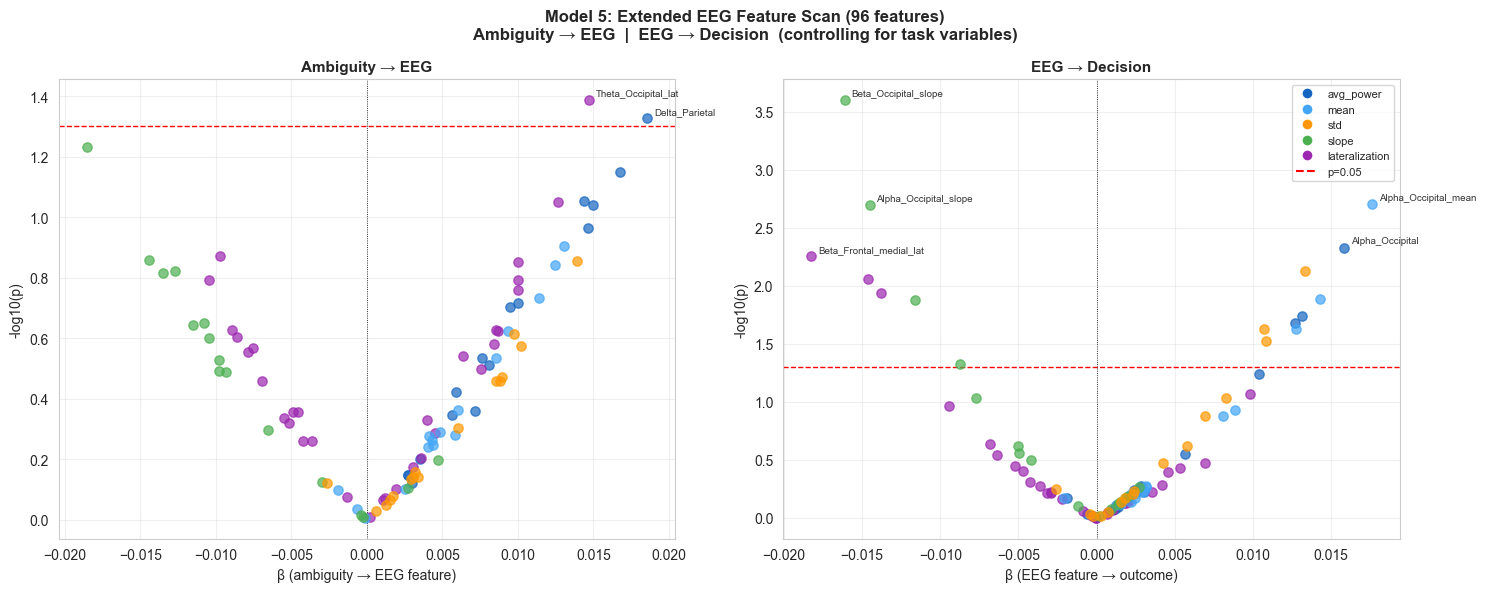

TOP EEG FEATURES — Ambiguity → EEG (sorted by p):
                                   feature           type  beta_ambig  p_ambig  sig_ambig
        eeg_Theta_Occipital_lateralization lateralization    0.014706 0.040934       True
                        eeg_Delta_Parietal      avg_power    0.018569 0.047078       True
                   eeg_Delta_Central_slope          slope   -0.018556 0.058587      False
                         eeg_Delta_Frontal      avg_power    0.016790 0.070690      False
                         eeg_Beta_Parietal      avg_power    0.014405 0.088158      False
eeg_Theta_Temporal_anterior_lateralization lateralization    0.012683 0.088961      False
                       eeg_Delta_Occipital      avg_power    0.014970 0.090830      False
                         eeg_Delta_Central      avg_power    0.014679 0.108704      False
                   eeg_Delta_Parietal_mean           mean    0.013031 0.124186      False
           eeg_Beta_Central_lateralization lateral

In [123]:
type_colors = {
    'avg_power':     '#1565C0',
    'mean':          '#42A5F5',
    'std':           '#FF9800',
    'slope':         '#4CAF50',
    'lateralization':'#9C27B0',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Model 5: Extended EEG Feature Scan (96 features)\n'
             'Ambiguity → EEG  |  EEG → Decision  (controlling for task variables)',
             fontsize=12, fontweight='bold')

for ax, (xcol, ycol, xlabel, title) in zip(axes, [
    ('beta_ambig',   'p_ambig',   'β (ambiguity → EEG feature)', 'Ambiguity → EEG'),
    ('beta_outcome', 'p_outcome', 'β (EEG feature → outcome)',   'EEG → Decision'),
]):
    for ftype, grp in scan_df.groupby('type'):
        ax.scatter(grp[xcol], -np.log10(grp[ycol]),
                   color=type_colors.get(ftype, 'gray'),
                   alpha=0.7, s=45, label=ftype, zorder=3)
    ax.axhline(-np.log10(0.05), color='red', linestyle='--', linewidth=1, label='p=0.05')
    ax.axvline(0, color='black', linewidth=0.6, linestyle=':')
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('-log10(p)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    # Label top 5 by significance
    top5 = scan_df.nsmallest(5, ycol)
    for _, row in top5.iterrows():
        logy = -np.log10(row[ycol])
        if logy > -np.log10(0.05):
            short = row['feature'].replace('eeg_', '').replace('_lateralization', '_lat')
            ax.annotate(short, xy=(row[xcol], logy),
                        xytext=(5, 3), textcoords='offset points',
                        fontsize=7, color='#333333')

legend_elements = [Line2D([0], [0], marker='o', color='w',
                           markerfacecolor=c, markersize=8, label=t)
                   for t, c in type_colors.items()]
legend_elements.append(Line2D([0], [0], color='red', linestyle='--', label='p=0.05'))
axes[1].legend(handles=legend_elements, fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig('../../data/results/main/statistical_analyses/lmm_model5_eeg_scan.png',
            dpi=150, bbox_inches='tight')
plt.show()

print('TOP EEG FEATURES — Ambiguity → EEG (sorted by p):')
print(scan_df.sort_values('p_ambig').head(10)[
    ['feature', 'type', 'beta_ambig', 'p_ambig', 'sig_ambig']].to_string(index=False))

print('\nTOP EEG FEATURES — EEG → Decision (sorted by p):')
print(scan_df.sort_values('p_outcome').head(10)[
    ['feature', 'type', 'beta_outcome', 'p_outcome', 'sig_outcome']].to_string(index=False))

---
## Model 6 — Gaze Deep Dive: Where and How Subjects Look Under Ambiguity

Gaze data is available for all 102 subjects across all 12,107 trials — the best coverage of any modality.

The key scientific question is not just whether ambiguity affects gaze, but **how**:
- **Where** do people look? (`screen_x/y_mean`) — do they shift gaze toward specific stimulus elements under uncertainty?
- **How much do they scan?** (`gaze_dispersion_x/y`, `gaze_path_length`) — does ambiguity drive more exploratory gaze as subjects compare options?
- **How fast do they move?** (`gaze_velocity_mean`) — faster/more erratic movements under uncertainty?

Note: `fixation_ratio` and `saccade_ratio` are near-constant across trials (median=1.0 and 0.0) so they are excluded — they carry no within-subject variance to model.

We run the same two-direction scan as Model 5: ambiguity → gaze feature, and gaze feature → decision.

In [124]:
# Load gaze features — already in merged_df
gaze_cols = feature_data['gaze_cols']

# Drop near-constant features (no within-subject variance to model)
gaze_model_cols = [c for c in gaze_cols if c not in
                   ['gaze_valid_pct', 'fixation_ratio', 'saccade_ratio', 'saccade_count']]

print(f'All gaze features ({len(gaze_cols)}): {gaze_cols}')
print(f'\nModeling subset ({len(gaze_model_cols)}): {gaze_model_cols}')

# Build gaze dataframe — full subject coverage
gaze_keep = behavior_keep + gaze_model_cols
df_gaze = merged_df[gaze_keep].dropna(subset=gaze_model_cols).copy().reset_index(drop=True)
df_gaze = zscore_cols(df_gaze, ['ambiguity', 'ev_difference', 'running_invest_rate'] + gaze_model_cols)

print(f'\nGaze modeling set: {len(df_gaze)} trials, {df_gaze["subject_id"].nunique()} subjects')
print('\nVariance of gaze features (within-subject std, mean across subjects):')
ws_std = df_gaze.groupby('subject_id')[gaze_model_cols].std().mean()
print(ws_std.round(4).to_string())

All gaze features (20): ['gaze_valid_pct', 'gaze_x_mean', 'gaze_x_std', 'gaze_y_mean', 'gaze_y_std', 'screen_x_mean', 'screen_x_std', 'screen_y_mean', 'screen_y_std', 'gaze_velocity_mean', 'gaze_velocity_std', 'gaze_velocity_max', 'gaze_acceleration_mean', 'gaze_acceleration_std', 'fixation_ratio', 'saccade_ratio', 'saccade_count', 'gaze_dispersion_x', 'gaze_dispersion_y', 'gaze_path_length']

Modeling subset (16): ['gaze_x_mean', 'gaze_x_std', 'gaze_y_mean', 'gaze_y_std', 'screen_x_mean', 'screen_x_std', 'screen_y_mean', 'screen_y_std', 'gaze_velocity_mean', 'gaze_velocity_std', 'gaze_velocity_max', 'gaze_acceleration_mean', 'gaze_acceleration_std', 'gaze_dispersion_x', 'gaze_dispersion_y', 'gaze_path_length']

Gaze modeling set: 12107 trials, 102 subjects

Variance of gaze features (within-subject std, mean across subjects):
gaze_x_mean                 0.1016
gaze_x_std                  0.0332
gaze_y_mean                 0.0435
gaze_y_std                  0.0201
screen_x_mean        

In [125]:
# Scan: ambiguity → each gaze feature AND each gaze feature → outcome
gaze_ctrl = 'ev_difference_z + prev_outcome + running_invest_rate_z'

gaze_scan = []
for col in gaze_model_cols:
    zcol = f'{col}_z'
    if zcol not in df_gaze.columns:
        continue
    # Skip if within-subject variance is near zero
    ws_var = df_gaze.groupby('subject_id')[col].std().mean()
    if ws_var < 1e-6:
        continue
    try:
        fit_a = smf.mixedlm(
            f'{zcol} ~ ambiguity_z + {gaze_ctrl}',
            data=df_gaze, groups=df_gaze['subject_id']
        ).fit(reml=True, disp=False)
        fit_b = smf.mixedlm(
            f'outcome ~ {zcol} + ambiguity_z + {gaze_ctrl}',
            data=df_gaze, groups=df_gaze['subject_id']
        ).fit(reml=False, disp=False)
        gaze_scan.append({
            'feature':      col,
            'beta_ambig':   fit_a.fe_params['ambiguity_z'],
            'se_ambig':     fit_a.bse_fe['ambiguity_z'],
            'p_ambig':      fit_a.pvalues['ambiguity_z'],
            'beta_outcome': fit_b.fe_params[zcol],
            'se_outcome':   fit_b.bse_fe[zcol],
            'p_outcome':    fit_b.pvalues[zcol],
        })
    except Exception:
        pass

gaze_df = pd.DataFrame(gaze_scan)
gaze_df['sig_ambig']   = gaze_df['p_ambig']   < 0.05
gaze_df['sig_outcome'] = gaze_df['p_outcome'] < 0.05
gaze_df['ci_lo_ambig'] = gaze_df['beta_ambig'] - 1.96 * gaze_df['se_ambig']
gaze_df['ci_hi_ambig'] = gaze_df['beta_ambig'] + 1.96 * gaze_df['se_ambig']

print(f'Gaze scan complete: {len(gaze_df)} features tested')
print(f'  Sig ambiguity → gaze:  {gaze_df["sig_ambig"].sum()}')
print(f'  Sig gaze → outcome:    {gaze_df["sig_outcome"].sum()}')
print(f'  Sig both directions:   {(gaze_df["sig_ambig"] & gaze_df["sig_outcome"]).sum()}')
print()
print('FULL RESULTS — Ambiguity → Gaze (sorted by p):')
print(gaze_df.sort_values('p_ambig')[
    ['feature', 'beta_ambig', 'se_ambig', 'p_ambig', 'sig_ambig']].to_string(index=False))
print()
print('FULL RESULTS — Gaze → Decision (sorted by p):')
print(gaze_df.sort_values('p_outcome')[
    ['feature', 'beta_outcome', 'se_outcome', 'p_outcome', 'sig_outcome']].to_string(index=False))

Gaze scan complete: 16 features tested
  Sig ambiguity → gaze:  13
  Sig gaze → outcome:    3
  Sig both directions:   3

FULL RESULTS — Ambiguity → Gaze (sorted by p):
               feature  beta_ambig  se_ambig      p_ambig  sig_ambig
            gaze_x_std    0.120723  0.006852 1.775040e-69       True
            gaze_y_std   -0.132049  0.007686 3.658308e-66       True
           gaze_y_mean    0.069908  0.004226 1.851223e-61       True
          screen_x_std    0.056870  0.008041 1.526822e-12       True
     gaze_dispersion_x    0.054668  0.008139 1.856441e-11       True
         screen_y_mean   -0.018365  0.003239 1.435216e-08       True
     gaze_velocity_max    0.041941  0.008142 2.589491e-07       True
     gaze_dispersion_y    0.030385  0.008175 2.019354e-04       True
      gaze_path_length    0.030138  0.008147 2.163701e-04       True
     gaze_velocity_std    0.028583  0.007747 2.248146e-04       True
 gaze_acceleration_std    0.027625  0.007767 3.757572e-04       True
   

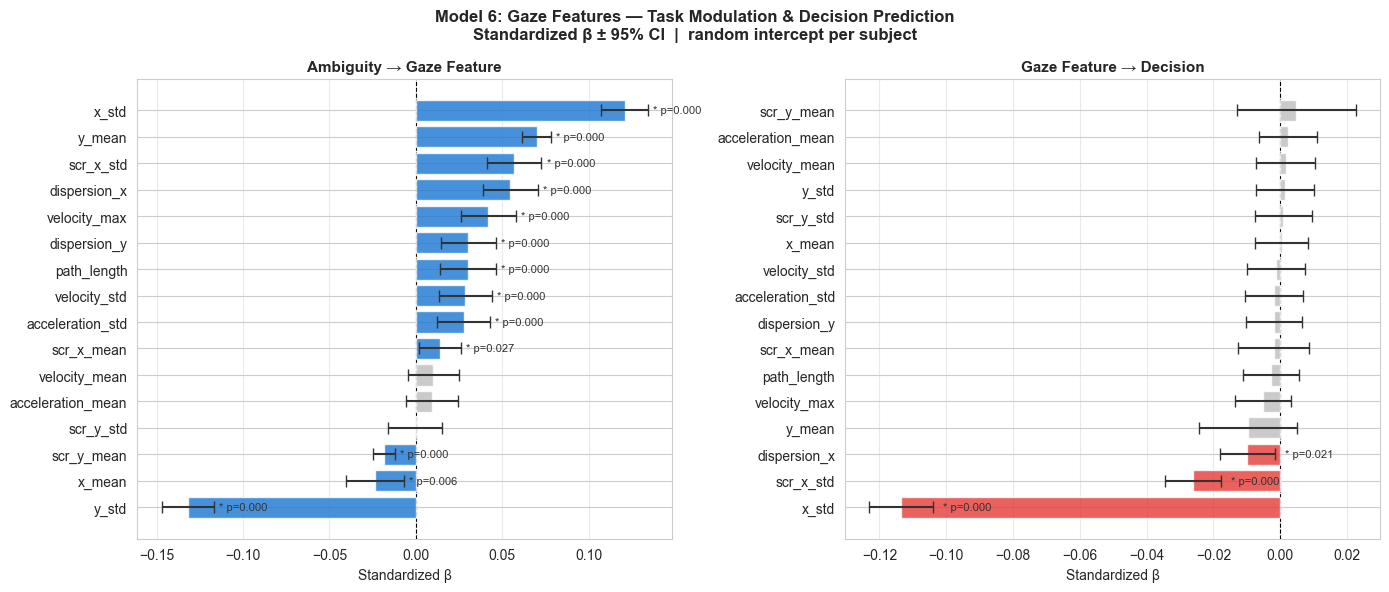

In [126]:
# Visualize: two-panel forest plot (ambiguity direction + outcome direction)
gaze_sorted_amb = gaze_df.sort_values('beta_ambig').reset_index(drop=True)
gaze_sorted_out = gaze_df.sort_values('beta_outcome').reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Model 6: Gaze Features — Task Modulation & Decision Prediction\n'
             'Standardized β ± 95% CI  |  random intercept per subject',
             fontsize=12, fontweight='bold')

for ax, df_plot, xcol, secol, sigcol, pcol, title, color in [
    (axes[0], gaze_sorted_amb, 'beta_ambig',   'se_ambig',   'sig_ambig',
     'p_ambig',   'Ambiguity → Gaze Feature', '#1976D2'),
    (axes[1], gaze_sorted_out, 'beta_outcome', 'se_outcome', 'sig_outcome',
     'p_outcome', 'Gaze Feature → Decision',  '#E53935'),
]:
    short_labels = [c.replace('gaze_', '').replace('screen_', 'scr_') for c in df_plot['feature']]
    bar_colors = [color if s else '#BDBDBD' for s in df_plot[sigcol]]
    ax.barh(short_labels, df_plot[xcol], color=bar_colors, alpha=0.8, zorder=3)
    ax.errorbar(df_plot[xcol], short_labels,
                xerr=1.96 * df_plot[secol], fmt='none',
                color='#333333', capsize=4, linewidth=1.5, zorder=4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Standardized β', fontsize=10)
    ax.grid(axis='x', alpha=0.4)
    for idx, row in df_plot.iterrows():
        if row[sigcol]:
            short = row['feature'].replace('gaze_', '').replace('screen_', 'scr_')
            ax.text(row[xcol] + 1.96 * row[secol] + 0.003, idx,
                    f'* p={row[pcol]:.3f}', va='center', fontsize=8, color='#333333')

plt.tight_layout()
plt.savefig('../../data/results/main/statistical_analyses/lmm_model6_gaze.png',
            dpi=150, bbox_inches='tight')
plt.show()


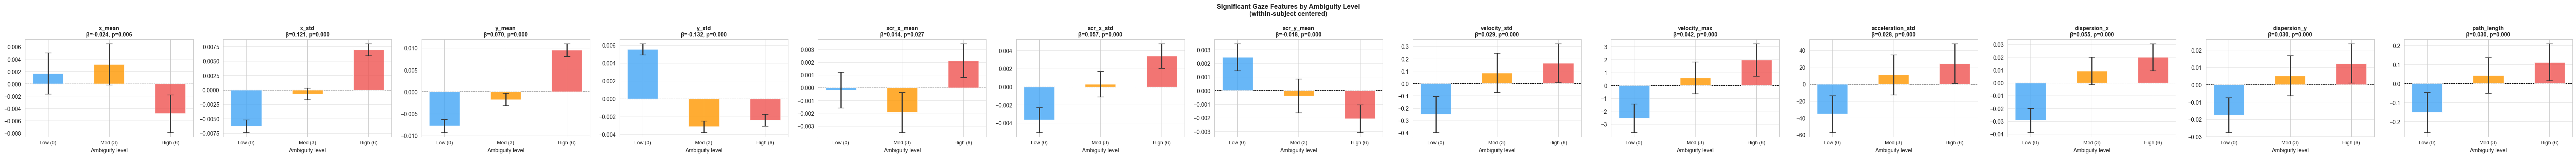

In [127]:
# Deep dive on the significant ambiguity → gaze features:
# Plot within-subject centered gaze feature means by ambiguity level
sig_amb_features = gaze_df[gaze_df['sig_ambig']]['feature'].tolist()

if sig_amb_features:
    n_sig = len(sig_amb_features)
    fig, axes = plt.subplots(1, n_sig, figsize=(5 * n_sig, 4), squeeze=False)
    fig.suptitle('Significant Gaze Features by Ambiguity Level\n(within-subject centered)',
                 fontsize=12, fontweight='bold')
    amb_labels = {0: 'Low (0)', 3: 'Med (3)', 6: 'High (6)'}
    colors = ['#42A5F5', '#FF9800', '#EF5350']

    for ax, feat in zip(axes[0], sig_amb_features):
        df_tmp = merged_df[['subject_id', 'ambiguity', feat]].dropna().copy()
        df_tmp['centered'] = df_tmp.groupby('subject_id')[feat].transform(lambda x: x - x.mean())
        gm = df_tmp.groupby('ambiguity')['centered'].agg(['mean', 'sem']).reset_index()
        x = list(range(len(gm)))
        ax.bar(x, gm['mean'], color=colors[:len(x)], alpha=0.8, width=0.5, zorder=3)
        ax.errorbar(x, gm['mean'], yerr=1.96 * gm['sem'], fmt='none',
                    color='#333333', capsize=6, linewidth=2, zorder=4)
        ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
        ax.set_xticks(x)
        ax.set_xticklabels([amb_labels.get(int(k), str(k)) for k in gm['ambiguity']], fontsize=9)
        short = feat.replace('gaze_', '').replace('screen_', 'scr_')
        row = gaze_df[gaze_df['feature'] == feat].iloc[0]
        ax.set_title(f'{short}\nβ={row["beta_ambig"]:.3f}, p={row["p_ambig"]:.3f}',
                     fontsize=10, fontweight='bold')
        ax.set_xlabel('Ambiguity level')
        ax.grid(axis='y', alpha=0.4)

    plt.tight_layout()
    plt.savefig('../../data/results/main/statistical_analyses/lmm_model6_gaze_by_ambiguity.png',
                dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No gaze features significantly modulated by ambiguity (p < 0.05).')

---
## Summary

In [128]:
print('='*70)
print('SUMMARY')
print('='*70)

print('\nMODEL 1 — Task Variables → Neural/Physio/Gaze Responses')
for fit, label in [(m1a_fit, 'Frontal Theta'), (m1b_fit, 'Beta Parietal'), (m1c_fit, 'Pupil Mean')]:
    b = fit.fe_params['ambiguity_z']
    p = fit.pvalues['ambiguity_z']
    print(f'  Ambiguity → {label}: β={b:.4f}, p={p:.3e} {"(sig.)" if p<0.05 else "(n.s.)"}')
print(f'  Model 1d (Gaze): {m1d_df["sig"].sum()} / {len(m1d_df)} features sig. driven by ambiguity')
if m1d_df['sig'].sum() > 0:
    top = m1d_df[m1d_df['sig']].sort_values('p_amb').head(3)
    for _, row in top.iterrows():
        direction = 'increases' if row['beta_amb'] > 0 else 'decreases'
        print(f'    {row["feature"]}: β={row["beta_amb"]:.4f}, p={row["p_amb"]:.3e} → {direction}')

print(f'\nMODEL 2 — Neural Signals → Decision')
print(f'  LRT: χ²({df_diff})={lr_stat:.2f}, p={p_lrt:.3e} {"(sig.)" if p_lrt<0.05 else "(n.s.)"}')
for feat, label in [
    ('eeg_Theta_Frontal_z', 'Frontal Theta'),
    ('eeg_Beta_Parietal_z', 'Beta Parietal'),
    ('pupil_mean_pre_z',    'Pupil Mean'),
]:
    b = m2_neural_fit.fe_params[feat]
    p = m2_neural_fit.pvalues[feat]
    print(f'  {label} → outcome: β={b:.4f}, p={p:.3e} {"(sig.)" if p<0.05 else "(n.s.)"}')

print(f'\nMODEL 3 — Mediation (Ambiguity → Theta → Decision)')
print(f'  Total (c):    β={c_total:.4f}, p={c_total_p:.3e}')
print(f"  Direct (c'):  β={c_prime:.4f}, p={c_prime_p:.3e}")
print(f'  Indirect a×b: {indirect:.5f}  |  Sobel z={sobel_z:.2f}, p={sobel_p:.3e}')
print(f'  Proportion mediated: {prop_med*100:.1f}%')

print(f'\nMODEL 4 — Pupil Deep Dive')
sig_pupil = pupil_res_df[pupil_res_df['sig']]
if len(sig_pupil):
    for _, row in sig_pupil.iterrows():
        direction = 'decreases' if row['beta_amb'] < 0 else 'increases'
        print(f'  Ambiguity → {row["feature"]}: β={row["beta_amb"]:.4f}, p={row["p_amb"]:.3e} → {direction} with ambiguity')
else:
    print('  No pupil features significantly modulated by ambiguity.')

print(f'\nMODEL 5 — Extended EEG Scan ({len(scan_df)} features)')
print(f'  Sig ambiguity → EEG:  {scan_df["sig_ambig"].sum()} features')
print(f'  Sig EEG → outcome:    {scan_df["sig_outcome"].sum()} features')
print(f'  Sig both directions:  {(scan_df["sig_ambig"] & scan_df["sig_outcome"]).sum()} features')
if scan_df['sig_ambig'].sum() > 0:
    top = scan_df[scan_df['sig_ambig']].nsmallest(3, 'p_ambig')
    print('  Top ambiguity hits:', ', '.join(top['feature'].tolist()))
if scan_df['sig_outcome'].sum() > 0:
    top = scan_df[scan_df['sig_outcome']].nsmallest(3, 'p_outcome')
    print('  Top outcome hits:  ', ', '.join(top['feature'].tolist()))

print(f'\nMODEL 6 — Gaze Deep Dive ({len(gaze_df)} features)')
print(f'  Sig ambiguity → gaze: {gaze_df["sig_ambig"].sum()} features')
print(f'  Sig gaze → outcome:   {gaze_df["sig_outcome"].sum()} features')
print(f'  Sig both directions:  {(gaze_df["sig_ambig"] & gaze_df["sig_outcome"]).sum()} features')
if gaze_df['sig_ambig'].sum() > 0:
    top = gaze_df[gaze_df['sig_ambig']].nsmallest(3, 'p_ambig')
    for _, row in top.iterrows():
        direction = 'increases' if row['beta_ambig'] > 0 else 'decreases'
        print(f'  Ambiguity → {row["feature"]}: β={row["beta_ambig"]:.4f}, p={row["p_ambig"]:.3e} → {direction}')
if gaze_df['sig_outcome'].sum() > 0:
    top = gaze_df[gaze_df['sig_outcome']].nsmallest(3, 'p_outcome')
    for _, row in top.iterrows():
        direction = 'invest' if row['beta_outcome'] > 0 else 'keep'
        print(f'  {row["feature"]} → outcome: β={row["beta_outcome"]:.4f}, p={row["p_outcome"]:.3e} → higher → more {direction}')


SUMMARY

MODEL 1 — Task Variables → Neural/Physio/Gaze Responses
  Ambiguity → Frontal Theta: β=-0.0064, p=4.924e-01 (n.s.)
  Ambiguity → Beta Parietal: β=-0.0071, p=4.787e-01 (n.s.)
  Ambiguity → Pupil Mean: β=-0.0170, p=2.877e-02 (sig.)
  Model 1d (Gaze): 13 / 16 features sig. driven by ambiguity
    gaze_x_std: β=0.1207, p=1.775e-69 → increases
    gaze_y_std: β=-0.1320, p=3.658e-66 → decreases
    gaze_y_mean: β=0.0699, p=1.851e-61 → increases

MODEL 2 — Neural Signals → Decision
  LRT: χ²(3)=8.08, p=4.446e-02 (sig.)
  Frontal Theta → outcome: β=-0.0149, p=7.062e-02 (n.s.)
  Beta Parietal → outcome: β=-0.0130, p=9.545e-02 (n.s.)
  Pupil Mean → outcome: β=-0.0035, p=5.812e-01 (n.s.)

MODEL 3 — Mediation (Ambiguity → Theta → Decision)
  Total (c):    β=-0.1595, p=2.714e-164
  Direct (c'):  β=-0.1597, p=8.103e-165
  Indirect a×b: 0.00010  |  Sobel z=0.64, p=5.210e-01
  Proportion mediated: -0.1%

MODEL 4 — Pupil Deep Dive
  Ambiguity → pupil_slope: β=0.0167, p=1.762e-02 → increases wi